In [ ]:
# import Libraries using
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
#Read the data
from google.colab import files #file from colab
uploaded=files.upload()

Saving insurance.csv to insurance (1).csv


In [ ]:
df= pd.read_csv('insurance.csv')


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
print(df.shape)

(1338, 7)


In [ ]:
#(EDA) Exploraty data analysis
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
#
df.isnull().sum() #No missing values

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<function matplotlib.pyplot.show(close=None, block=None)>

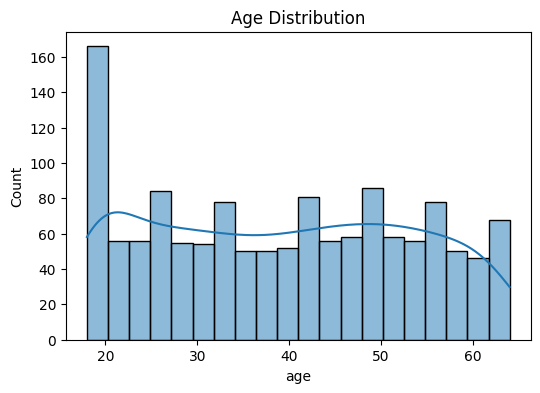

In [ ]:
#Data Visulzation
#distrubtio of age
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

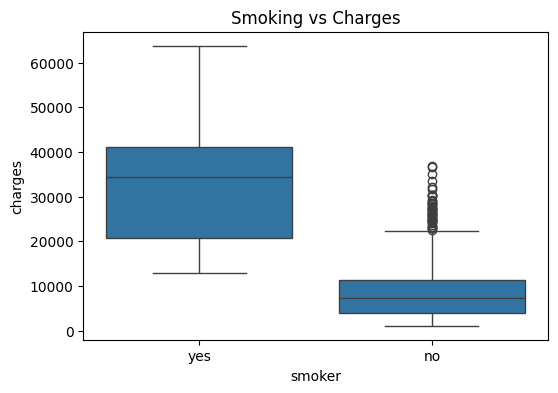

In [ ]:
#effect smoker for charges
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Smoking vs Charges')
plt.show

#smokers more the charges more
#this effect factor

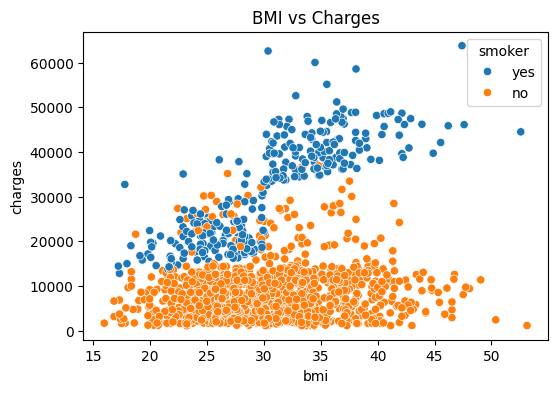

In [ ]:
#relation between bmi and charges
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Charges')
plt.show()
# The higher the BMI, the higher the cost, especially for smokers.

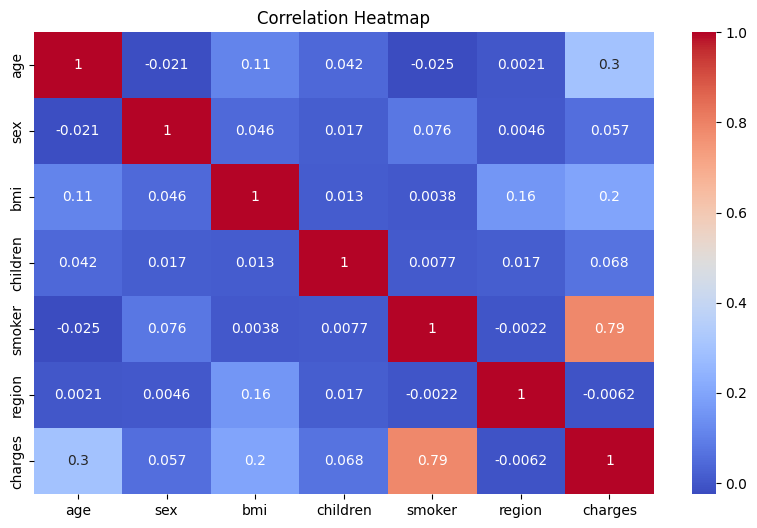

In [ ]:
# heatmap correlation
plt.figure(figsize=(10,6))
corr_matrix = df.corr() # Calculate the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm') # Pass the correlation matrix to heatmap

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Preprocessing
#coverts text to numbers

le = LabelEncoder()

for col in ['sex', 'smoker', 'region']: #text
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:


X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
#split data

#Training Data → learning
#Testing Data → testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# bulding ML model
#Linear Regression
model = LinearRegression()


In [ ]:
# training model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#predict
y_pred = model.predict(X_test)

In [ ]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result.head())



           Actual     Predicted
764    9095.06825   8924.407244
887    5272.17580   7116.295018
890   29330.98315  36909.013521
1293   9301.89355   9507.874691
259   33750.29180  27013.350008


In [ ]:
#performance model
#Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print('MAE:', mae)

MAE: 4186.508898366433



##The average difference between the actual and expected values.

##The lower the difference, the better the model.

In [ ]:
#Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

MSE: 33635210.431178406


In [ ]:
#Root Mean Squared Error
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 5799.587091438356


In [ ]:
#R² Score
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)

R2 Score: 0.7833463107364539


##R² Explained

##Measures the quality of the model.

#Close to 1 → Excellent
#Close to 0 → Poor

In [ ]:
#Identifying the most influential factors
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

#Smoking is the biggest contributing factor.
#Age has a clear impact.
#BMI also has an impact.

    Feature   Coefficient
0       age    257.056264
1       sex    -18.791457
2       bmi    335.781491
3  children    425.091456
4    smoker  23647.818096
5    region   -271.284266


In [ ]:
# New data experiment for prediction
new_data = pd.DataFrame({
    'age': [30],
    'sex': [1],
    'bmi': [28.5],
    'children': [2],
    'smoker': [0],
    'region': [1]
})

prediction = model.predict(new_data)

print('Predicted Insurance Charges:', prediction)

Predicted Insurance Charges: [5894.96102461]


#Key Findings from the Analysis

#Smoking is the strongest factor in increasing insurance costs.

#Increased BMI is associated with increased costs.

#Age has a clear impact on costs.

#The Linear Regression model performed well in its prediction.